In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
E_list = [] 

for i in range(0, 300):
    
    print("Processing event:", f"{i:02}")
    path = Path(f"/swgo/Array_Simulato_Analisi_ML/roots_mPMT_gammas_SWGO_array/4FF_R600m_h175r180_black_uniform0600m_100300TeV_030deg/DAT1000{i:02}.root")

    if not path.exists():
        continue
        
    DAT = uproot.open(
        f"/swgo/Array_Simulato_Analisi_ML/roots_mPMT_gammas_SWGO_array/"
        f"4FF_R600m_h175r180_black_uniform0600m_100300TeV_030deg/"
        f"DAT1000{i:02}.root")

    if "XCDF" not in DAT:
        continue
    tree = DAT["XCDF"]
    df = tree.arrays(library = "pd")
    max_num_evts = np.nanmax(df["HAWCSim.Evt.Num"])

    for j in range(0, max_num_evts):
        p0 = df[df["HAWCSim.Evt.Num"] == j] #3 WORKS WELL
        if p0.empty:
            continue 
        p_E = np.asarray(p0['HAWCSim.Evt.Energy'].iloc[0])
        p_E = p_E/1000
        E_list.append(p_E)

Processing event: 00
Processing event: 01
Processing event: 02
Processing event: 03
Processing event: 04
Processing event: 05
Processing event: 06
Processing event: 07
Processing event: 08
Processing event: 09
Processing event: 10
Processing event: 11
Processing event: 12
Processing event: 13
Processing event: 14
Processing event: 15
Processing event: 16
Processing event: 17
Processing event: 18
Processing event: 19
Processing event: 20
Processing event: 21
Processing event: 22
Processing event: 23
Processing event: 24
Processing event: 25
Processing event: 26
Processing event: 27
Processing event: 28
Processing event: 29
Processing event: 30
Processing event: 31
Processing event: 32
Processing event: 33
Processing event: 34
Processing event: 35
Processing event: 36
Processing event: 37
Processing event: 38
Processing event: 39
Processing event: 40
Processing event: 41
Processing event: 42
Processing event: 43
Processing event: 44
Processing event: 45
Processing event: 46
Processing ev

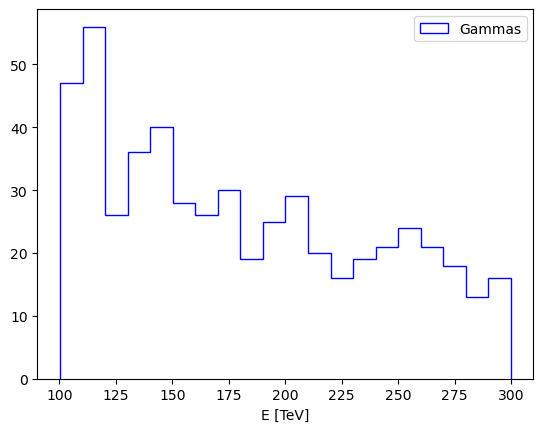

In [9]:
plt.hist(E_list, histtype = "step", color = "blue", label = "Gammas", bins = 20)
plt.xlabel(r"E [TeV]")
plt.legend()
plt.savefig("pictures/other/spectrum_gamma.png", dpi = 300)
plt.show()